# Neural Manifold Analysis Pipeline

Builds the neural encoding manifolds by 
(1) Loading and preprocessing activity data
(2) Preparing data for tensor decomposition
(3) Loading decomposition results
(4) Select number of factors R to use for decomposition
(5) Filtering out outliers
(6) Applying IAN + diffusion maps to obtain the manifold

## Table of Contents
- [Parameters to Set](#parameters-to-set)
- [Load Data](#load-data)
- [Process Tensor Data](#process-tensor-data-smoothing-and-selecting-frequencies)
- [Save Tensor for Tensor Decomposition](#save-tensor-for-tensor-decomposition)
- [Load Decomposition Result](#load-decomposition-result)
- [Plot Total Normalized Explained Variance](#plot-total-normalized-explained-variance)
- [Choose Number of Factors R](#choose-number-of-factors-r)
- [Replot with Factors R](#replot-highlighting-for-factors-r)
- [Visualize Factors](#visualize-factors)
- [Data Processing](#data-processing)
- [Outlier Analysis](#outlier-analysis---visualizing-distance-distributions-and-potential-outliers)
- [Run IAN](#run-ian)
- [Graph Analysis](#graph-analysis)
- [Plot 2D Manifold](#plot-2d-manifold)
- [Compute MDS Embedding](#compute-mds-embedding-for-better-visualization)
- [Plot 3D Manifold](#plot-3d-manifold)

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.cm
import logging
import os
import json
from scipy.io import savemat
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import pdist, squareform
from scipy import sparse
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, leaves_list, optimal_leaf_ordering, dendrogram
from sklearn.decomposition import PCA, KernelPCA
from hdbscan.hdbscan_ import _tree_to_labels
from hdbscan.plots import CondensedTree
import plotly.graph_objects as go
from matplotlib.backends.backend_pdf import PdfPages

from tueplots import bundles
from tueplots.constants.color import rgb
import sys, os; _d = os.path.abspath(os.getcwd()); sys.path.insert(0, _d if os.path.isdir(os.path.join(_d, 'src')) else os.path.dirname(_d))
from src import *

from ian.ian import * #https://github.com/dyballa/IAN/
from ian.embed_utils import *
from ian.dset_utils import *
from ian.utils import *

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams.update(bundles.neurips2021(usetex=False))

results_dict = {}

## Parameters to set

In [36]:
# ════════════════════════════════════════════════════════════════════════════
# CONFIG — edit only this cell before running the notebook
# ════════════════════════════════════════════════════════════════════════════

#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs0_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks0_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs1_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks1_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_inputs2_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_blocks2_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_hidden_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_recurrentout_maxFr_maxNr_seed1"
#PREFIX = "fnn07_act_i3_n2000_SCL0_7_TL37_position_maxFr_maxNr_seed1"
PREFIX = "fnn07_seed2"  # 1000 neurons

#PREFIX = "Retina"
#PREFIX = "V1"

#PREFIX = "flyvis_Retina_i3_n400_model000"
#PREFIX = "flyvis_Lamina_i3_n350_model000"
#PREFIX = "flyvis_Medulla_i3_n550_model000"
#PREFIX = "flyvis_T_Tm_i3_n1700_model000"

#PREFIX = "VISal_natural_movie_one_scenes20"
PREFIX = "VISal_natural_movie_one_scenes_all156"
#PREFIX = "VISam_natural_movie_one_scenes20"
#PREFIX = "VISam_natural_movie_one_scenes_all156"
#PREFIX = "VISl_natural_movie_one_scenes20"
#PREFIX = "VISl_natural_movie_one_scenes_all156"
#PREFIX = "VISp_natural_movie_one_scenes20"
#PREFIX = "VISp_natural_movie_one_scenes_all156"
#PREFIX = "VISpm_natural_movie_one_scenes20"
#PREFIX = "VISpm_natural_movie_one_scenes_all156"
#PREFIX = "VISrl_natural_movie_one_scenes20"
#PREFIX = "VISrl_natural_movie_one_scenes_all156"

#PREFIX = "cornet_s_V1_i3_n2000_seed17"
#PREFIX = "cornet_s_V2_i3_n2000_seed17"
#PREFIX = "cornet_s_V4_i3_n2000_seed17"
#PREFIX = "cornet_s_IT_i3_n1960_seed17"

#PREFIX = "mousenet_LGNv_i3_n200_seed17"
#PREFIX = "mousenet_VISp4_i3_n1000_seed17"
#PREFIX = "mousenet_VISp2_3_i3_n1000_seed17"
#PREFIX = "mousenet_VISp5_i3_n1000_seed17"
#PREFIX = "mousenet_VISl2_3_i3_n840_seed17" 
#PREFIX = "mousenet_VISal2_3_i3_n600_seed17" 
#PREFIX = "mousenet_VISrl2_3_i3_n880_seed17" 
#PREFIX = "mousenet_VISli2_3_i3_n360_seed17" 
#PREFIX = "mousenet_VISpl2_3_i3_n680_seed17" 

PREFIX = "allen_VISal"
#PREFIX = "allen_VISam"
#PREFIX = "allen_VISl"
#PREFIX = "allen_VISpm"
#PREFIX = "allen_VISp"
#PREFIX = "allen_VISrl"

PREFIX = "r2plus1d_layer1_i3_n2000_seed17"
#PREFIX = "r2plus1d_layer2_i3_n2000_seed17"
#PREFIX = "r2plus1d_layer3_i3_n2000_seed17"
#PREFIX = "r2plus1d_layer4_i3_n1960_seed17"

PREFIX = "vit_b_16_n2000"
PREFIX = "vit_b_16_L11_n2000_frames"



# R > 0 : skip auto-suggest, use this value directly.
# R = 0 : auto-suggest from elbow heuristic (inspect plot, then override in next cell if needed).
R = 10

# If True the plot cell computes a suggested R from the derivative inflection and Cell B adopts it.
# Set False to enter R manually in Cell B.
AUTO_SUGGEST_R = False

optSF      = True        # use per-neuron optimal spatial frequency
method     = 'relNorm'   # normalisation method
smooth_sig = 3           # smoothing window in frames (50 ms at 60 Hz)

basedir_data = '../data/sampled'
basedir_mat  = '../data/decompositions'
basedir_wG   = '../data/graphs'

# backward-compat alias (used by load-data cell)
basedir = basedir_data

# ── Tensor decomposition mode ─────────────────────────────────────────────
# USE_PYTHON_CP = False  →  load pre-computed MATLAB .mat files (default)
# USE_PYTHON_CP = True   →  run Python ALS decomposition (no MATLAB needed);
#                            loads cached .mat files if already computed.
USE_PYTHON_CP = True

# Python CP settings (only used when USE_PYTHON_CP = True)
CP_NREPS    = 5   # random restarts (30 = production, 5 = quick preview)
CP_MAX_ITER = 200  # ALS iterations per rep
CP_N_JOBS   = 1    # parallel jobs (-1 = all cores; uses more RAM)

# Control execution of advanced analysis sections
run_advanced_analysis = False

# Ensure output figure directories exist before any savefig calls
for _d in ['../fig/manifolds', '../fig/3d_manifolds', '../fig/component_choices',
           '../fig/factor_activities']:
    os.makedirs(_d, exist_ok=True)

print(f'PREFIX        = {PREFIX}')
print(f'R             = {R}  (0 → auto-suggest)')
print(f'AUTO_SUGGEST_R= {AUTO_SUGGEST_R}')
print(f'method        = {method!r}  smooth_sig={smooth_sig}  optSF={optSF}')
print(f'USE_PYTHON_CP = {USE_PYTHON_CP}'
      + (f'  (nreps={CP_NREPS}, n_jobs={CP_N_JOBS})' if USE_PYTHON_CP else ''))


PREFIX        = vit_b_16_L11_n2000_frames
R             = 10  (0 → auto-suggest)
AUTO_SUGGEST_R= False
method        = 'relNorm'  smooth_sig=3  optSF=True
USE_PYTHON_CP = True  (nreps=5, n_jobs=1)


## Load data

In [37]:
#load activity data
tensor4d = np.nan_to_num(np.load(f'{basedir}/tensor4d_{PREFIX}.npy'))
tensor4d = tensor4d - np.min(tensor4d)

neurons_used = np.load(f'{basedir}/neurons_used_{PREFIX}.npy')
print(f"(Neurons, Stimuli, Orientation, Trial len): {tensor4d.shape}")

(Neurons, Stimuli, Orientation, Trial len): (2000, 11, 8, 37)


## Process tensor data: smoothing and selecting frequencies

In [38]:
tensorX, relFRs, optStims = process_tensor_data(tensor4d, optSF, smooth_sig, method)

N, _, NDIRS, TRIAL_LEN = tensor4d.shape
NSTIMS = tensorX.shape[1]  # updated after optSF filtering
PREFIX2 = f'{method}_sig{smooth_sig}_n{N}'
if optSF and optStims:  # only if SF filtering was actually applied (skipped for non-11-stim tensors)
    PREFIX2 += '_SF'

CPMETHOD = 'shift'
AREA = 'deepnet'
tensorname = '%s-%s-%s-%s' % (PREFIX,PREFIX2,AREA,CPMETHOD)

print(NSTIMS)

6


## Save / Run Tensor Decomposition


In [39]:
# ── Option A: save tensor as .mat for MATLAB (skipped when USE_PYTHON_CP=True) ──
if not USE_PYTHON_CP:
    force_save = False
    os.makedirs(basedir_mat, exist_ok=True)
    tfname = f'{basedir_mat}/{tensorname}.mat'
    if not os.path.exists(tfname) or force_save:
        savemat(tfname, {'X': tensorX})
        print(f'Saved tensor → {tfname}')
    else:
        print(f'Tensor file exists: {tfname}  (set force_save=True to overwrite)')
    print('\nNow run MATLAB tensor decomposition:')
    print(f'  run_permcp(\'{tensorname}\', \'shift\', 2, 15, 30, 8)')
    print('Then re-run the cells below to load the results.')

# ── Option B: run Python ALS decomposition (no MATLAB required) ───────────
else:
    print(f'Running Python CP decomposition (USE_PYTHON_CP=True)')
    print(f'  tensorname = {tensorname}')
    print(f'  nreps={CP_NREPS}  max_iter={CP_MAX_ITER}  n_jobs={CP_N_JOBS}')
    print(f'  Cached .mat files in {basedir_mat}/ will be loaded if available.')
    _F_range = range(R, R + 1) if R > 0 else range(2, 16)
    preComputed = load_or_run_cp(
        tensorX, tensorname,
        F_range=_F_range,
        NDIRS=NDIRS,
        nreps=CP_NREPS,
        max_iter=CP_MAX_ITER,
        n_jobs=3,
        basedir=basedir_mat,
        verbose=True,
    )
    Fs = sorted(preComputed.keys())
    print(f'  Done. Available F: {Fs}')


Running Python CP decomposition (USE_PYTHON_CP=True)
  tensorname = vit_b_16_L11_n2000_frames-relNorm_sig3_n2000_SF-deepnet-shift
  nreps=5  max_iter=200  n_jobs=1
  Cached .mat files in ../data/decompositions/ will be loaded if available.
../data/decompositions/vit_b_16_L11_n2000_frames-relNorm_sig3_n2000_SF-deepnet-shift*_F*.mat
Running Python CP for F=[10]


CP F=10: 100%|██████████| 5/5 [00:00<00:00, 82.49it/s]


  Done. Available F: [10]


## Load MATLAB Decomposition Result

*(Skipped when `USE_PYTHON_CP = True` — results were already loaded above.)*


## Load Decomposition Result

In [40]:
if USE_PYTHON_CP:
    # preComputed and Fs already populated by the Python CP cell above.
    pass
else:
    # Discover available R values for this tensorname before loading.
    import glob as _glob, re as _re
    _available_Rs = sorted(set(
        int(_re.search(r'_F(\d+)', f).group(1))
        for f in _glob.glob(f'{basedir_mat}/{tensorname}*_F*.mat')
        if _re.search(r'_F(\d+)', f)
    ))
    if _available_Rs and R not in _available_Rs:
        _fallback = _available_Rs[0] if len(_available_Rs) == 1 else None
        if _fallback is not None:
            print(f'R={R} not found; only available decomposition is R={_fallback}. Overriding.')
            R = _fallback
        else:
            print(f'R={R} not found; available: {_available_Rs}. Update R in CONFIG cell.')

    # Load all decompositions when auto-suggesting R (need the full curve),
    # or just the chosen R when it's already known.
    _specificFs = None if (AUTO_SUGGEST_R or R <= 0) else [R]
    preComputed, Fs = loadPreComputedCP(tensorname, basedir_mat, specificFs=_specificFs, verbose=1)


## Plot total normalized explained variance

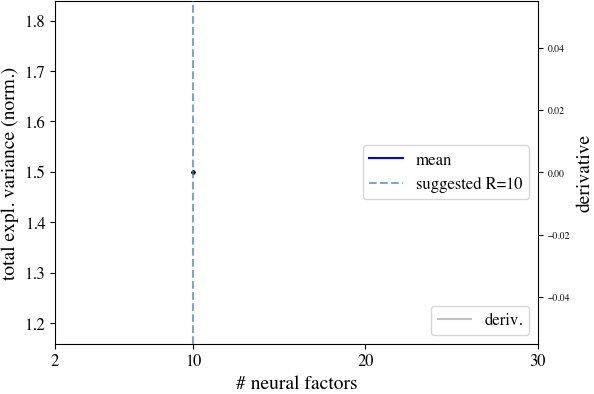

In [41]:
nfacs = np.array(Fs)
NEURALMODE = 0
mus = []
stds = []

LGD_SZ = 12
LBL_SZ = 14
TICK_SZ = 12

for nf in nfacs:
    #collect factors for all available repetitions
    neuralfs = np.array([preComputed[nf]['all_factors'][repi][NEURALMODE] for repi in sorted(preComputed[nf]['all_factors'])])
    #normalize
    neuralfs = [f/from0to1(np.linalg.norm(f,axis=0,keepdims=1)) for f in neuralfs]
    
    nucl_norms = []
    
    reps_used = list(preComputed[nf]['all_lambdas'])###
    
    for repi in range(len(preComputed[nf]['all_factors'])):

        A = neuralfs[repi].copy()
        Si = A.T
        Si -= Si.mean(0)
        #compute explained variances
        s = np.linalg.svd(Si,full_matrices=False,compute_uv=False)
        var = s**2/(Si.shape[0]-1)   
        #normalize
        var /= var.max()
        # compute nuclear norm (sum of eigenvals)
        nucl_norms.append( var.sum() )

    mus.append(np.mean(nucl_norms))
    stds.append(np.std(nucl_norms))

mus  = np.array(mus)
stds = np.array(stds)
grads = np.diff(gaussian_filter1d(mus, 1.5))

# ── Auto-suggest R at inflection point ──────────────────────────────────────
if AUTO_SUGGEST_R:
    noise_threshold   = 0.05 * np.abs(grads).max()
    candidates        = np.where(np.abs(grads) < noise_threshold)[0]
    suggested_R       = int(nfacs[1:][candidates[0]]) if len(candidates) else int(nfacs[len(nfacs)//2])
    print(f'Suggested R = {suggested_R}  '
          f'(inflection-point heuristic — inspect plot and override in next cell if needed)')
else:
    suggested_R = R if R > 0 else int(nfacs[len(nfacs)//2])

f,ax1 = subps(1,1,4,6)
ax1.plot(nfacs, mus,'b-', label='mean')
ax1.plot(nfacs, mus,'kD',markersize=2)

ax1_ = ax1.twinx()
ax1_.plot(nfacs[1:],grads,c='silver',label='deriv.',zorder=0)
ax1_.set_ylabel('derivative',size=LBL_SZ)
ax1_.legend(loc="lower right",fontsize=LGD_SZ)
ax1.fill_between(nfacs,mus-stds,mus+stds,alpha=.4)
ax1.set_xlabel('# neural factors',size=LBL_SZ)
ax1.set_ylabel('total expl. variance (norm.)',size=LBL_SZ)
ax1.set_xticks([2]+list(range(10,31,10)))
ax1.tick_params(labelsize=TICK_SZ)
ax1.legend(loc="center right",fontsize=LGD_SZ)
ax1.set_zorder(ax1_.get_zorder()+1)
ax1.set_frame_on(False)

# Mark suggested R
ax1.axvline(suggested_R, color='steelblue', linestyle='--', alpha=0.7,
            label=f'suggested R={suggested_R}', zorder=10)
ax1.legend(loc="center right", fontsize=LGD_SZ)

plt.show()

## Choose Number of Factors R

Based on the above plot of explained variance, select the number of factors R to use. This choice is non-trivial. For a detailed description of the choice, refer to the supplemental material in Dyballa et al. (2024)

As a heuristic: Choose R at an inflection point, before the noise fitted increases with more factors. The encoding manifolds are relatively stable to small changes in R. R should be above 5 always.

In [42]:
# ── Choose R ─────────────────────────────────────────────────────────────────
# If AUTO_SUGGEST_R is True, suggested_R was computed in the plot cell above.
# Override here if needed — e.g.: R = 7
if AUTO_SUGGEST_R:
    R = suggested_R
# else: R was set in the CONFIG cell and stays as-is.

# Safety: if R is not available but only one decomposition was loaded, use it.
if R not in preComputed and Fs:
    print(f'R={R} not in preComputed; using R={Fs[0]} (available: {Fs}).')
    R = Fs[0]

results_dict["R"] = R

rep, error = min(preComputed[R]['all_objs'].items(), key=lambda x: x[1])
best_rep = rep
print(f'R = {R},  best rep = {best_rep}  (error = {error:.3f})')

R = 10,  best rep = 0  (error = 1.653)


## Replot, highlighting for Factors R

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_36973/1867443850.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(nfacs, mus,'b-', label='mean', color=rgb.tue_red)
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_36973/1867443850.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kD" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(nfacs, mus,'kD',markersize=2, color=rgb.tue_red)
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_36973/1867443850.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax1.plot([R,R],[mus.min(),mus[list(nfacs).index(R)]],'r--',label=f'R={R}',zorder=10, color=rgb.tue_darkblue)


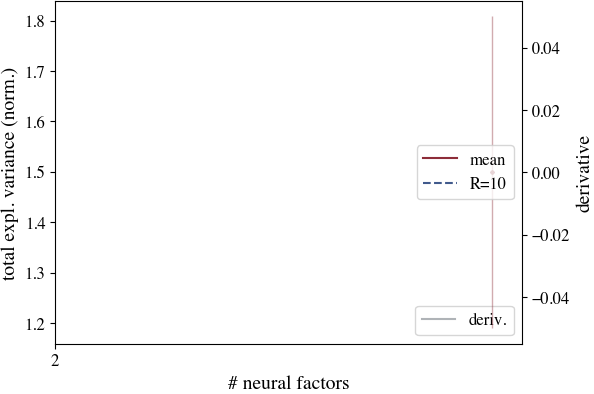

In [43]:
f,ax1 = subps(1,1,4,6)
ax1.plot(nfacs, mus,'b-', label='mean', color=rgb.tue_red)
ax1.plot(nfacs, mus,'kD',markersize=2, color=rgb.tue_red)

mus = np.array(mus)
ax1.plot([R,R],[mus.min(),mus[list(nfacs).index(R)]],'r--',label=f'R={R}',zorder=10, color=rgb.tue_darkblue)
grads = np.diff(gaussian_filter1d(mus,1.5))
ax1_ = ax1.twinx()
ax1_.plot(nfacs[1:],grads,c=rgb.tue_gray,label='deriv.',zorder=0)
ax1_.set_ylabel('derivative',size=LBL_SZ)
ax1_.legend(loc="lower right",fontsize=LGD_SZ)
stds = np.array(stds)
ax1.fill_between(nfacs,mus-stds,mus+stds,alpha=.4, color=rgb.tue_red)
ax1.set_xlabel('# neural factors',size=LBL_SZ)
ax1.set_ylabel('total expl. variance (norm.)',size=LBL_SZ)
ax1.set_xticks([2]+list(range(10,len(mus),10)))
ax1.tick_params(labelsize=TICK_SZ)
ax1_.tick_params(labelsize=TICK_SZ)
ax1.legend(loc="center right",fontsize=LGD_SZ)
ax1.set_zorder(ax1_.get_zorder()+1)
ax1.set_frame_on(False)

# save plot
plt.savefig(f'../fig/component_choices/{tensorname}_expl_var.png')
plt.show()

## Visualize Factors

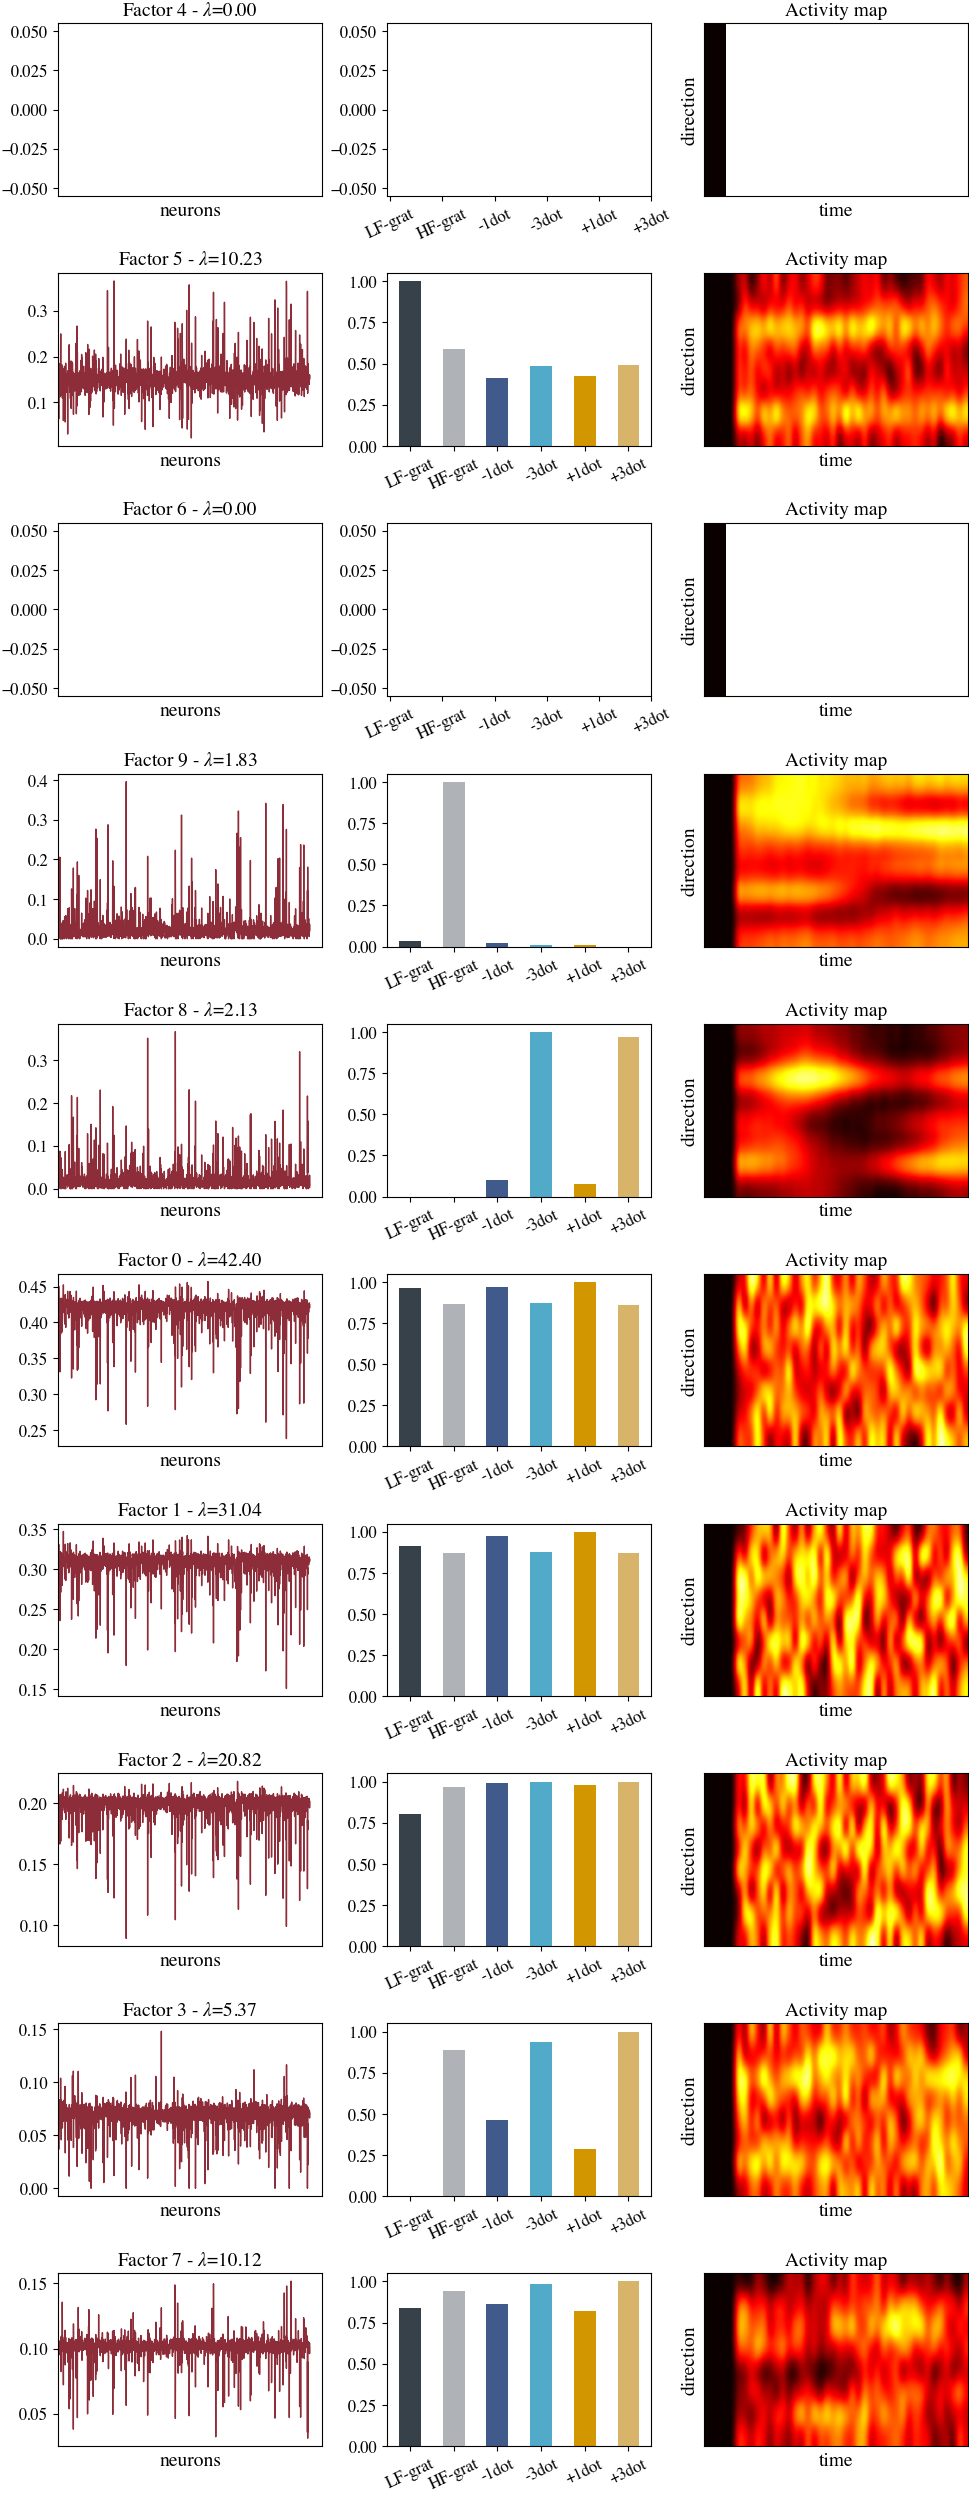

In [44]:
# best_rep was determined in the factor selection cell above (minimum reconstruction error).
best_factors = preComputed[R]['all_factors'][best_rep]
best_lambdas = preComputed[R]['all_lambdas'][best_rep]

posnorms = ~np.isclose(best_lambdas,0)
posnorms = posnorms | ~posnorms
best_lambdas = best_lambdas[posnorms]
nfactors = [f[:,posnorms]/np.linalg.norm(f[:,posnorms],axis=0,keepdims=1) for f in best_factors]

_KNOWN_STIM_LABELS = {
    6:  ['LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot'],
    11: ['LF-grat', 'HF-grat', '-1dot', '-3dot', '+1dot', '+3dot',
         'HF-grat-2', '-1dot-2', '-3dot-2', '+1dot-2', '+3dot-2'],
}
actual_nstim = tensorX.shape[1]
my_stims = _KNOWN_STIM_LABELS.get(actual_nstim, [f'stim {i}' for i in range(actual_nstim)])

leaves = range(nfactors[0].shape[0])

_BASE_COLORS = [rgb.tue_dark, rgb.tue_gray, rgb.tue_darkblue, rgb.tue_lightblue,
                rgb.tue_orange, rgb.tue_lightorange, 'red', 'blue', 'yellow', 'green', 'pink', 'teal']
import math as _math
colors = (_BASE_COLORS * _math.ceil(actual_nstim / len(_BASE_COLORS)))[:actual_nstim]

ncols = 3; colsz = 3.25
nrows = R; rowsz = 2.5

#sort factors by predominant stim (%)
sorted_factors = np.argsort((nfactors[1]).argmax(axis=0))

#rebalance factor loadings, scale by lambdas
stim_factors = nfactors[1].copy()
stim_scls = stim_factors.max(0,keepdims=1)
stim_factors /= stim_scls

neural_factors = nfactors[0].copy()
neural_factors *= best_lambdas
neural_factors *= stim_scls

fig, axes = plt.subplots(len(neural_factors[0]), ncols, figsize=(colsz*ncols, len(neural_factors[0])*rowsz))

for ll,l in enumerate(sorted_factors):

    ax = axes[ll,0]
    ax.set_title(r'Factor %d - $\lambda$=%.2f' % (l,best_lambdas[l]),size=LBL_SZ)
    ax.plot(neural_factors[leaves,l],lw=1,c=rgb.tue_red)
    ax.set_xlim(0,ax.get_xlim()[1])
    ax.set_xticks([])
    ax.set_xlabel('neurons',size=LBL_SZ)
    ax.tick_params(axis='y', labelsize=TICK_SZ)
    
    ax = axes[ll,1]
    ax.bar(range(actual_nstim),stim_factors[:,l],width=.5,
            color=colors[:actual_nstim],tick_label=my_stims)

    ax.tick_params(axis='x', labelrotation=25, labelsize=TICK_SZ)
    ax.tick_params(axis='y', labelsize=TICK_SZ)

    ax = axes[ll,2]
    pst = nfactors[2][:,l].reshape(NDIRS,-1,order='F')
    # circular-shift response map to opt dir (for better visualization)
    opt_dir = pst.mean(1).argmax()
    pst = np.roll(pst,(2-opt_dir)%NDIRS,0)
    pst -= pst.min()
    # cosmetics: pad with zeros to mimic a "pre stimulus interval" when visualizing PSTHs
    pst = np.concatenate([np.zeros((NDIRS,5)),pst],axis=1)  
    ax.imshow(pst,aspect='auto',interpolation='quadric',cmap='hot')
    ax.set_title('Activity map', size=LBL_SZ)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel('direction', size=LBL_SZ); ax.set_xlabel('time', size=LBL_SZ)

# save plot
plt.savefig(f'../fig/factor_activities/{tensorname}_factors.png')
plt.show()

## Data processing

[[-2.72875419e-02  3.46154999e-03  1.11565382e-02 ...  6.75755565e-03
   4.40624847e-04 -5.95686117e-05]
 [ 3.52017798e-02 -3.10652984e-02  4.14854219e-02 ...  1.30721368e-02
   1.72786846e-03 -1.51880057e-04]
 [-4.45757719e-02  1.32783312e-02 -5.91969143e-03 ... -2.37646371e-03
   3.34432678e-04  1.36380830e-04]
 ...
 [-2.66544869e-02 -3.61469698e-02 -4.93137625e-03 ... -9.24387712e-04
   1.57768958e-04  3.44025430e-04]
 [ 7.07046851e-02  4.18416005e-03 -3.74771608e-03 ...  2.68101560e-03
  -8.63346269e-04 -2.90654387e-05]
 [-4.50693141e-02 -5.54574184e-02  1.78735164e-03 ...  1.52772474e-03
  -5.66653973e-05 -1.30007415e-04]]
nPCs=np.int64(2)


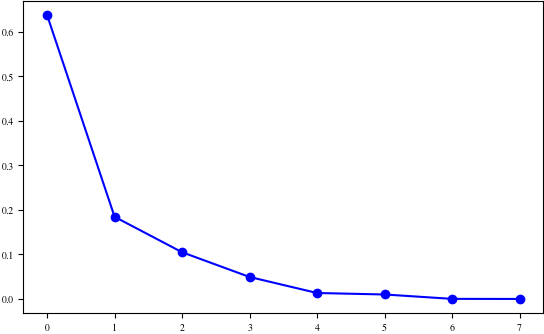

In [45]:
# remove any eventual zero-norm factor
posnorms = ~np.isclose(best_lambdas,0)
lambdas = best_lambdas[posnorms]
# make sure they are all normalized
factors = [f[:,posnorms]/np.linalg.norm(f[:,posnorms],axis=0,keepdims=1) for f in best_factors]

# find the permuted version of sigT that gave rise to the factors -- this is
# necessary for computing the actual rec error
# replace nans with 0s
sigT = tensorX
permT, fitT = getPermutedTensor(factors, lambdas, sigT, NDIRS)

all_zeroed_stims = None
scld_permT = permT #simplified for CNNs, since tensor was pre-scaled by FRs (see above)

X, all_scld_permT = getNeuralMatrix(
    scld_permT, factors, lambdas, NDIRS, all_zeroed_stims, order='F', verbose=False)

# optionally, eliminate possible redundancy among factors in the neural matrix using PCA
# (this is mostly used to ensure a more fair comparison across brain areas / networks, since they might use
# different numbers of tensor components)

MIN_EXPL_VAR_RATIO = 0.8

pca = PCA(len(lambdas))
pcaX = pca.fit_transform(X)
print(pcaX)

# number of PCs can be chosen based on a prespecified explained variance ratio,
nPCs = np.flatnonzero(np.cumsum(pca.explained_variance_ratio_) > MIN_EXPL_VAR_RATIO)[0] + 1
print(f'{nPCs=}')
results_dict["nPCs"] = nPCs

# or simply by inspection of the variance spectrum
plt.plot(pca.explained_variance_ratio_, 'bo-')
# nPCs = 

X = pcaX[:,:nPCs]

# compute matrix of squared distances
D2 = pwdists(X, sqdists=True)
N = D2.shape[0]

## Outlier analysis - visualizing distance distributions and potential outliers

Outliers (most distant): 542,1814,398,1919,1788,154,1528,1760,1532
Original indices: 542,1814,398,1919,1788,154,1528,1760,1532
Outliers (most similar): 1124,1011,1003,663,1424,1727,320,636,1570,1566
Original indices: 1124,1011,1003,663,1424,1727,320,636,1570,1566


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_36973/4274475753.py:56: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


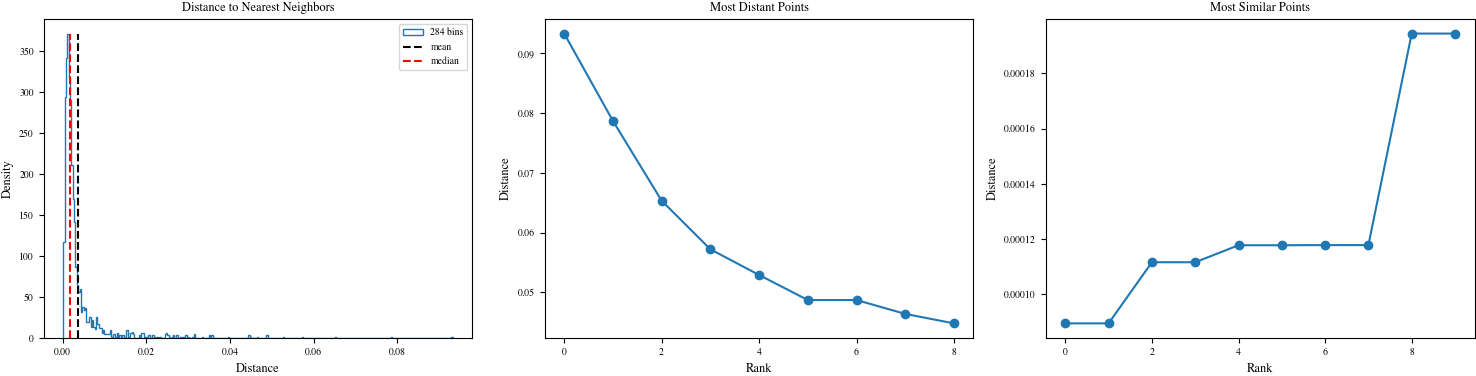

In [46]:
# especially for CNNs, it's a good idea to remove any obvious outliers before running IAN
nonoutliers = np.arange(D2.shape[0])
# this histogram of distance to nearest nbrs helps identifying them (if present)
# wanna remove points that have either this 1-NN distance too close to 0 (e.g. two neurons that had near zero response to everything)
# or neurons that were too different than everything else

D1 = np.sqrt(D2)
mindists = np.min(D1 + np.eye(N)*D1.max(),axis=0)
meanmind = mindists.mean()
medianmind = np.median(mindists)

# Create subplots to show outlier analysis together
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of minimum distances
for n_bins in ['fd']:#,'doane','stone']:
    if type(n_bins) is str:
        try:
            bin_edges = np.histogram_bin_edges(mindists,n_bins)
        except:
            continue
        n_bins = len(bin_edges)-1
    counts,edges,_ = axes[0].hist(mindists,n_bins,histtype='step',density=True,label=f'{n_bins} bins')
axes[0].plot([meanmind,meanmind],[0,counts.max()],'k--',label='mean')
axes[0].plot([medianmind,medianmind],[0,counts.max()],'r--',label='median')
axes[0].legend()
axes[0].set_title('Distance to Nearest Neighbors')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Density')

# Check indices of points that might be too far away from all other points
mean_dists = mindists
n = 9
axes[1].plot(sorted(mean_dists)[::-1][:n])
axes[1].scatter(range(n),sorted(mean_dists)[::-1][:n])
axes[1].set_xticks(range(0,n,2))
axes[1].set_title('Most Distant Points')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Distance')
outls = np.argsort(mean_dists)[::-1][:n]
print('Outliers (most distant):',','.join(map(str,outls)))
print('Original indices:',','.join(map(str,nonoutliers[outls])))

# ... and check for points that might be way too close to one another (nearly-identical)
n_close = 10
axes[2].plot(sorted(mean_dists)[:n_close])
axes[2].scatter(range(n_close),sorted(mean_dists)[:n_close])
axes[2].set_xticks(range(0,n_close,2))
axes[2].set_title('Most Similar Points')
axes[2].set_xlabel('Rank')
axes[2].set_ylabel('Distance')
outls_close = np.argsort(mean_dists)[:n_close]
print('Outliers (most similar):',','.join(map(str,outls_close)))
print('Original indices:',','.join(map(str,nonoutliers[outls_close])))

plt.tight_layout()
plt.show()


In [47]:
too_far = nonoutliers[outls][:2] # check idxs of a few most faraway points
too_close = nonoutliers[outls_close][:5] # check idxs of a few points that are almost identical to discard

# build a short list of potential outliers and remove them from the analysis -- this can greatly improve the visualization
outliers_list = np.append(too_far, too_close)

myX = X[[c for c in range(X.shape[0]) if c not in outliers_list]]
# keep track of original idxs of the actual neurons being used
nonoutliers = np.array([i for i in range(X.shape[0]) if i not in outliers_list])

# compute matrix of squared distances
D2 = pwdists(myX, sqdists=True)

# update N
N = D2.shape[0]

## Run IAN

Running IAN (this may take several minutes)...
### Iteration 1 done. (0.24 s) - pruned 6 edge(s)
### Iteration 2 done. (0.10 s) - pruned 5 edge(s)
### Iteration 3 done. (0.11 s) - pruned 5 edge(s)
### Iteration 4 done. (0.10 s) - pruned 5 edge(s)
### Iteration 5 done. (0.10 s) - pruned 5 edge(s)
### Iteration 6 done. (0.10 s) - pruned 4 edge(s)
### Iteration 7 done. (0.10 s) - pruned 4 edge(s)
### Iteration 8 done. (0.10 s) - pruned 4 edge(s)
### Iteration 9 done. (0.12 s) - pruned 4 edge(s)
### Iteration 10 done. (0.10 s) - pruned 4 edge(s)
### Iteration 11 done. (0.10 s) - pruned 4 edge(s)
### Iteration 12 done. (0.11 s) - pruned 4 edge(s)
### Iteration 13 done. (0.10 s) - pruned 4 edge(s)
### Iteration 14 done. (0.10 s) - pruned 3 edge(s)
### Iteration 15 done. (0.10 s) - pruned 3 edge(s)
### Iteration 16 done. (0.10 s) - pruned 3 edge(s)
### Iteration 17 done. (0.10 s) - pruned 3 edge(s)
### Iteration 18 done. (0.10 s) - pruned 2 edge(s)
### Iteration 19 done. (0.10 s) - pruned 2 e

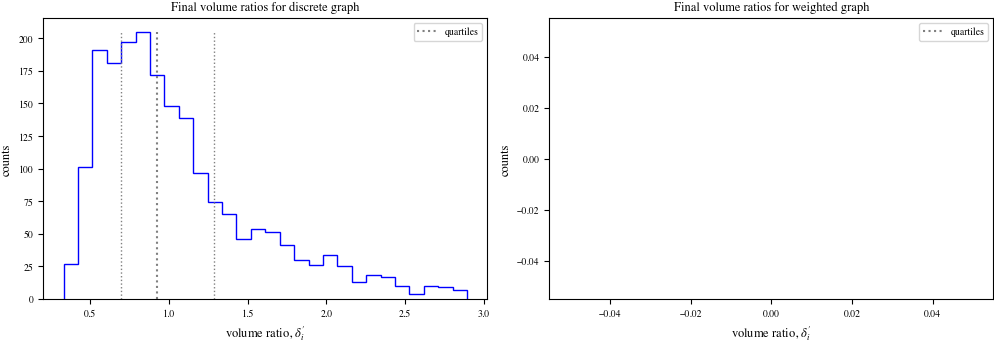

IAN computed and cached → ../data/graphs/vit_b_16_L11_n2000_frames_10.npz


In [48]:
# ── IAN graph — loads from cache if available, otherwise computes (slow) ──
# Cache key is  {PREFIX}_{R}.npz  (PREFIX encodes the layer, R encodes the rank).
# WARNING: if you change R, delete the cached .npz first — the cache key does
# not include R in the filename structure, so stale graphs can be silently reused.
wG_path = f'{basedir_wG}/{PREFIX}_{R}.npz'

if os.path.exists(wG_path):
    _cache    = np.load(wG_path, allow_pickle=False)
    wG_dense  = _cache['wG']
    wG        = csr_matrix(wG_dense)
    G         = (wG_dense > 0).astype(float)
    optScales = _cache['optScales']
    disc_pts  = [[i] for i in _cache['disc_pts_indices']]
    print(f'Loaded cached IAN from {wG_path}')
else:
    print('Running IAN (this may take several minutes)...')
    # use None if you don't have a preferred solver, or pick from the list of
    # solvers in cvxpy: https://www.cvxpy.org/tutorial/advanced/index.html
    # A free Gurobi academic license can speed this up significantly.
    solver = None
    G, wG, optScales, disc_pts = IAN('exact-precomputed-sq', D2, solver=solver)
    os.makedirs(basedir_wG, exist_ok=True)
    _disc_indices = np.array([disc_pts[di][0] for di in range(len(disc_pts))], dtype=np.int64)
    np.savez(wG_path, wG=wG.toarray(), optScales=optScales, disc_pts_indices=_disc_indices)
    print(f'IAN computed and cached → {wG_path}')


## Graph Analysis

In [49]:
# Compute graph connectivity statistics
graph_stats = compute_graph_statistics(wG, neurons_used, nonoutliers)

# Extract individual lists for backward compatibility
degrees = graph_stats['degrees']
weighted_degrees = graph_stats['weighted_degrees']
same_fmaps = graph_stats['same_fmaps']
other_fmaps = graph_stats['other_fmaps']

# Update results dictionary with graph statistics
for key in ['degree_mean', 'degree_min', 'degree_max', 'degree_std',
            'weighted_degree_mean', 'weighted_degree_min', 'weighted_degree_max', 'weighted_degree_std',
            'same_fmap_mean', 'same_fmap_min', 'same_fmap_max', 'same_fmap_std',
            'other_fmap_mean', 'other_fmap_min', 'other_fmap_max', 'other_fmap_std']:
    results_dict[key] = graph_stats[key]

print(f"Mean of degrees = {graph_stats['degree_mean']}")
print(f"Min of degrees = {graph_stats['degree_min']}")
print(f"Max of degrees = {graph_stats['degree_max']}")
print(f"Std of degrees = {graph_stats['degree_std']}\n")
print(f"Mean of weighted degrees = {graph_stats['weighted_degree_mean']}")
print(f"Min of weighted degrees = {graph_stats['weighted_degree_min']}")
print(f"Max of weighted degrees = {graph_stats['weighted_degree_max']}")
print(f"Std of weighted degrees = {graph_stats['weighted_degree_std']}\n")
print(f"Mean number of connections to same fmap neurons = {graph_stats['same_fmap_mean']}")
print(f"Min number of connections to same fmap neurons = {graph_stats['same_fmap_min']}")
print(f"Max number of connections to same fmap neurons = {graph_stats['same_fmap_max']}")
print(f"Std number of connections to same fmap neurons = {graph_stats['same_fmap_std']}\n")
print(f"Mean number of connections to other fmap neurons = {graph_stats['other_fmap_mean']}")
print(f"Min number of connections to other fmap neurons = {graph_stats['other_fmap_min']}")
print(f"Max number of connections to other fmap neurons = {graph_stats['other_fmap_max']}")
print(f"Std number of connections to other fmap neurons = {graph_stats['other_fmap_std']}")

# Handle disconnected points from IAN optimization
wG, G, outliers_list, nonoutliers, nonout_mask = handle_disconnected_points(
    disc_pts, optScales, G, D2, outliers_list, neurons_used, X)

print(f"Number of disconnected points: {len([disc_pts[di][0] for di in range(len(disc_pts))])}")
print(f"Total outliers: {len(outliers_list)}")
print(f"Remaining points: {len(nonoutliers)}")

Mean of degrees = 26.253888610135473
Min of degrees = 2
Max of degrees = 1992
Std of degrees = 45.458115966865975

Mean of weighted degrees = inf
Min of weighted degrees = inf
Max of weighted degrees = inf
Std of weighted degrees = nan

Mean number of connections to same fmap neurons = 0.1445057701956849
Min number of connections to same fmap neurons = 0
Max number of connections to same fmap neurons = 5
Std number of connections to same fmap neurons = 0.39208318169312556

Mean number of connections to other fmap neurons = 26.10938283993979
Min number of connections to other fmap neurons = 1
Max number of connections to other fmap neurons = 1987
Std number of connections to other fmap neurons = 45.33935240315667
Number of disconnected points: 1
Total outliers: 8
Remaining points: 1992


## Plot 2D Manifold

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_36973/2125941366.py:39: UserWarning: The figure layout has changed to tight
  f.tight_layout()


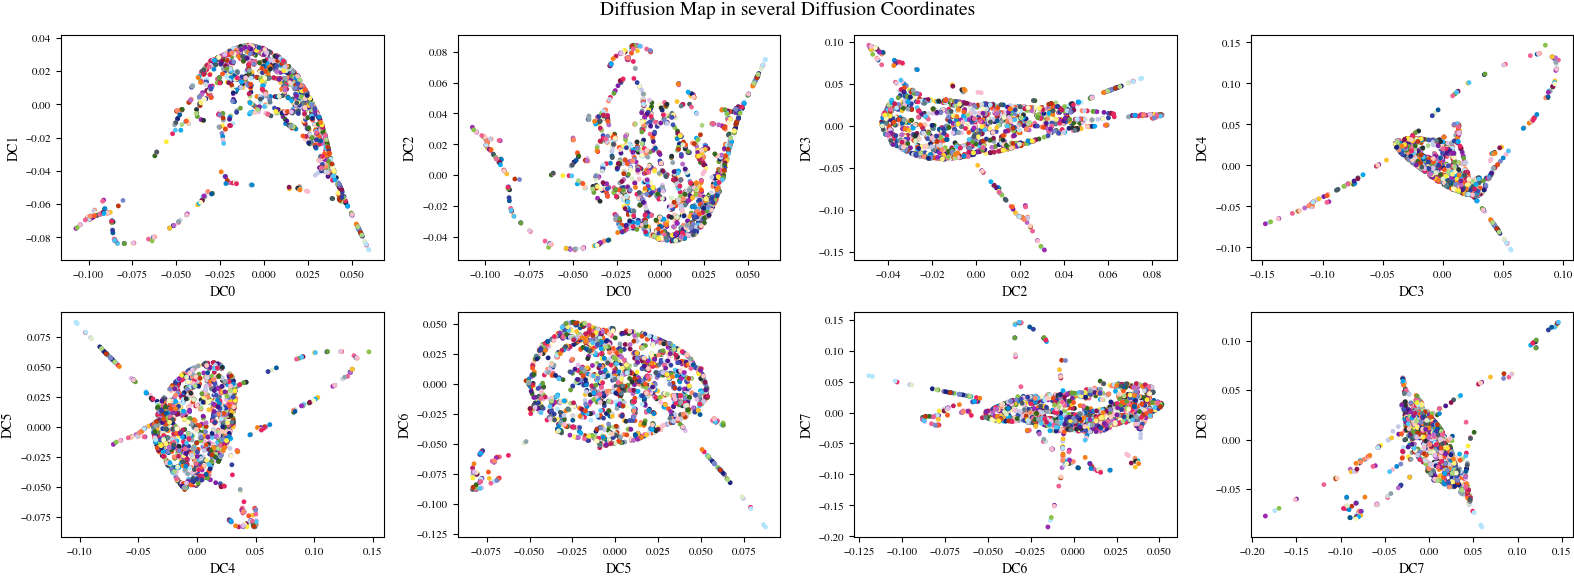

In [50]:
# Colors to differentiate clusters in the diffusion map
palstr = np.array([
    '#03579b', '#0488d1', '#03a9f4', '#4fc3f7', '#b3e5fc', 
    '#19237e', '#303f9f', '#3f51b5', '#7986cb', '#c5cae9', 
    '#4a198c', '#7b21a2', '#9c27b0', '#ba68c8', '#e1bee7', 
    '#88144f', '#c21f5b', '#e92663', '#f06292', '#f8bbd0', 
    '#bf360c', '#e64a18', '#ff5722', '#ff8a65', '#ffccbc', 
    '#f67f17', '#fbc02c', '#ffec3a', '#fff177', '#fdf9c3', 
    '#33691d', '#689f38', '#8bc34a', '#aed581', '#ddedc8',  
    '#253137', '#455a64', '#607d8b', '#90a4ae', '#cfd8dc'
])
from scipy.sparse import csr_matrix
diffmap_y, diffmap_evals = diffusionMapSparseK(csr_matrix(wG), 20, 1, t=1)

c = neurons_used[nonoutliers,1] # labels for the different feature maps
#c = neurons_used[:60, 1]

ulbls, labels = np.unique(c,return_inverse=True)

repeat = np.max(labels) // 40 + 1
palstr = np.repeat(palstr, repeat)

cluster_colors = [palstr[li] for li in labels]

# flip thru diff coords to see the multiple clusters (usually strongly associated with a specific feature map)
DCs = [(0,1), (0,2), (2,3), (3,4),
      (4,5), (5,6), (6,7), (7,8)]

PCs = diffmap_y

f, axes = subps(2, len(DCs)//2, 3, 4)

for ax, (dci, dcj) in zip(axes.ravel(), DCs):
    ax.scatter(*diffmap_y[:,[dci, dcj]].T,c=cluster_colors,s=6)
    ax.set_xlabel(f'DC{dci}', size=LBL_SZ-4)
    ax.set_ylabel(f'DC{dcj}', size=LBL_SZ-4)
    ax.tick_params(labelsize=TICK_SZ-4)
f.suptitle("Diffusion Map in several Diffusion Coordinates", size=LBL_SZ)
f.tight_layout()

plt.savefig(f'../fig/manifolds/{tensorname}_{R}_diffmaps.png')

plt.show()

## Compute MDS embedding for better visualization

In [54]:
# Apply MDS to the diffusion map coordinates for better 3-D visualization.
# The diffusion map lives in a high-dimensional DC space; MDS finds the best
# low-dimensional Euclidean layout that preserves pairwise geodesic distances,
# giving a more isometric embedding for 3-D plotting than taking the first 3 DCs.
embedding_ = compute_mds_embedding(diffmap_y, nPCs, n_components=10)
#embedding_ = diffmap_y


## Plot 3D Manifold

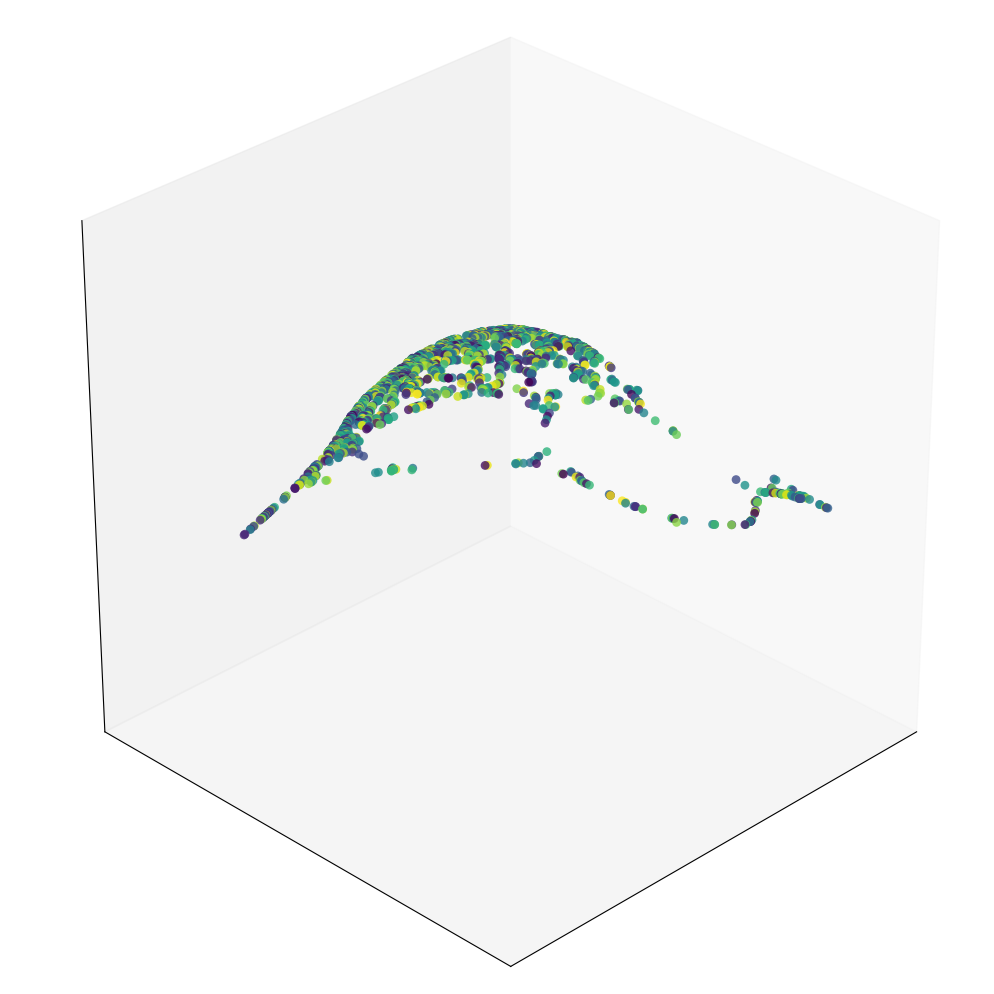

In [57]:
Y = embedding_

# pick 3 coords to plot
dcs = [0,1,2]
# --- 1. Setup Data & Colors (Matching your logic) ---
# Ensure mypal is a numpy array for the concatenation logic to work
mypal = np.array(palstr) 
colors = neurons_used[nonoutliers, 2]
fmapis = np.unique(colors)

# Replicate the palette extension logic
while len(mypal) < len(fmapis):
    mypal = np.r_[mypal, mypal]

# Subsample the palette
mypal = mypal[np.arange(0, len(mypal), len(mypal) // len(fmapis))]

# --- 2. Initialize Figure ---
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# --- 3. Plotting Loop ---
"""for fi, fmapi in enumerate(fmapis):
    color_mask = colors == fmapi
    
    # Plotly size=4 is roughly area~16 in Matplotlib (s is points^2)
    # We use s=20 for visibility
    ax.scatter(
        Y[color_mask, dcs[0]],
        Y[color_mask, dcs[1]],
        Y[color_mask, dcs[2]],
        c=mypal[fi],       # Use the calculated palette color
        s=40,              # Marker size
        alpha=0.8,         # Opacity
        edgecolors='none', # Remove outlines for cleaner clusters
        depthshade=False   # Match Plotly's "flat" color (no distance fading)
    )"""

#for fi, fmapi in enumerate(fmapis):
#    color_mask = colors == fmapi
    
    # Plotly size=4 is roughly area~16 in Matplotlib (s is points^2)
    # We use s=20 for visibility
ax.scatter(
    Y[:, dcs[0]],
    Y[:, dcs[1]],
    Y[:, dcs[2]],
    c=neurons_used[nonoutliers, 1],       #mypal[fi],       # Use the calculated palette color
    cmap='viridis',
    s=40,              # Marker size
    alpha=0.8,         # Opacity
    edgecolors='none', # Remove outlines for cleaner clusters
    depthshade=False   # Match Plotly's "flat" color (no distance fading)
)

# --- 4. Styling (Clean "Plotly White" imitation) ---

# Remove gray background panes
#ax.xaxis.pane.fill = False
#ax.yaxis.pane.fill = False
#ax.zaxis.pane.fill = False

# Remove grid lines
ax.grid(False)

# Remove tick labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Style the axis lines (Spines) to be black and visible
ax.xaxis.line.set_color('black')
ax.yaxis.line.set_color('black')
ax.zaxis.line.set_color('black')

# Optional: Enforce a cubic aspect ratio so the manifold isn't distorted
ax.set_box_aspect([1, 1, 1])

ax.view_init(elev=30, azim=45)

# --- 5. Save as PDF ---
output_path = f'../fig/3d_manifolds/{tensorname}_{R}_diffmap.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close(fig)

In [53]:
for key, val in results_dict.items():
    results_dict[key] = float(val)

with open(f"../data/metrics/{tensorname}_{R}_metrics.json", "w") as outfile:
    json.dump(results_dict, outfile)